In [1]:
import pandas as pd
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from collections import Counter
from sklearn.metrics import average_precision_score

c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Note: LinearRegression/Lasso/Elastic Net/Ridge did not make sense for the fraud use case (binary classification). So I instead use Logistic Reg with different penalty

In [2]:
random_state=42

In [3]:
classification_reports = []
classification_report_keys = []

## IBM

### Data

In [4]:
# Import IBM dataset
df = pd.read_csv('C:/Users/caleb/Projects/BU Spring 2026/Module-B-semester-2/Milestone 3 EDA/ibm_hi_small_trans_cleaned.csv')
df

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Amount Paid,Is Laundering,Amount_Received_USD,Amount_Paid_USD,...,Payment Currency_Yuan,Payment Format_ACH,Payment Format_Bitcoin,Payment Format_Cash,Payment Format_Cheque,Payment Format_Credit Card,Payment Format_Reinvestment,Payment Format_Wire,Account_Same,Bank_Same
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.340000,3697.340000,0,3697.340000,3697.340000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.010000,0.010000,0,0.010000,0.010000,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.570000,14675.570000,0,14675.570000,14675.570000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.970000,2806.970000,0,2806.970000,2806.970000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.970000,36682.970000,0,36682.970000,36682.970000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5078340,2022/09/10 23:57,54219,8148A6631,256398,8148A8711,0.154978,0.154978,0,3107.386389,3107.386389,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0
5078341,2022/09/10 23:35,15,8148A8671,256398,8148A8711,0.108128,0.108128,0,2168.020464,2168.020464,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0
5078342,2022/09/10 23:52,154365,8148A6771,256398,8148A8711,0.004988,0.004988,0,100.011894,100.011894,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0
5078343,2022/09/10 23:46,256398,8148A6311,256398,8148A8711,0.038417,0.038417,0,770.280058,770.280058,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,1


In [5]:
df.drop(columns=['Timestamp', 'From Bank', 'To Bank', 'Account', 'Account.1'], inplace=True)

### Undersampling

In [6]:
from collections import Counter


X = df.drop(columns='Is Laundering')
y = df['Is Laundering']
print("Original dataset shape:", Counter(y))
rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X, y)

print("Resampled dataset shape:", Counter(y_resampled))

Original dataset shape: Counter({0: 5073168, 1: 5177})
Resampled dataset shape: Counter({0: 5177, 1: 5177})


### Split Data

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, 
                                                    y_resampled, 
                                                    test_size=0.2, 
                                                    stratify=y_resampled,  # Maintains class distribution
                                                    random_state=random_state
                                                    )

### Baseline Models
#### (No parameter optimization, feature scaling, or cross validation)

#### Linear Regression

In [8]:
model = LogisticRegression()

In [9]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [10]:
y_pred = model.predict(X_test)

In [11]:
print(classification_report(y_true=y_test, y_pred=y_pred))
report = classification_report(y_true=y_test, y_pred=y_pred, output_dict=True)
df_temp = pd.DataFrame(report).transpose()

classification_reports.append(df_temp)
classification_report_keys.append('Baseline Logistic Regression')

              precision    recall  f1-score   support

           0       1.00      0.01      0.02      1036
           1       0.50      1.00      0.67      1035

    accuracy                           0.50      2071
   macro avg       0.75      0.50      0.34      2071
weighted avg       0.75      0.50      0.34      2071



In [12]:
average_precision_score(y_true=y_test, y_score=y_pred)

0.5016965584100824

#### Ridge

In [13]:
from sklearn.linear_model import RidgeClassifier


ridge_model = RidgeClassifier(random_state=random_state)

In [14]:
ridge_model.fit(X_train, y_train)

c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\linear_model\_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=2.80134e-23): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,class_weight,None
,solver,'auto'
,positive,False
,random_state,42


In [15]:
y_pred = ridge_model.predict(X_test)

In [16]:
print(classification_report(y_true=y_test, y_pred=y_pred))
report = classification_report(y_true=y_test, y_pred=y_pred, output_dict=True)
df_temp = pd.DataFrame(report).transpose()

classification_reports.append(df_temp)
classification_report_keys.append('Baseline Ridge Classifier')


              precision    recall  f1-score   support

           0       0.88      0.89      0.89      1036
           1       0.89      0.88      0.88      1035

    accuracy                           0.89      2071
   macro avg       0.89      0.89      0.89      2071
weighted avg       0.89      0.89      0.89      2071



In [17]:
average_precision_score(y_true=y_test, y_score=y_pred)

0.8432307187875231

#### Lasso

In [18]:
lasso_model = LogisticRegression(penalty='l1', solver='liblinear')

In [19]:
lasso_model.fit(X_train, y_train)

c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,penalty,'l1'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [20]:
y_pred = lasso_model.predict(X_test)

In [21]:
print(classification_report(y_true=y_test, y_pred=y_pred))
report = classification_report(y_true=y_test, y_pred=y_pred, output_dict=True)
df_temp = pd.DataFrame(report).transpose()

classification_reports.append(df_temp)
classification_report_keys.append('Baseline L1 (Lasso) Logistic Regression')

              precision    recall  f1-score   support

           0       0.88      0.89      0.89      1036
           1       0.89      0.88      0.88      1035

    accuracy                           0.89      2071
   macro avg       0.89      0.89      0.89      2071
weighted avg       0.89      0.89      0.89      2071



In [22]:
average_precision_score(y_true=y_test, y_score=y_pred)

0.8432307187875231

### Scaling Data

In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Parameter Tuning

#### Logistic Regression

In [24]:
# We can only tune the C (float) and Class_weight to tryout balanced. 

In [25]:
# cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_state)
from sklearn.model_selection import StratifiedKFold


cv = StratifiedKFold(n_splits=5)

In [26]:
def objective(trial):
    c = trial.suggest_float("C", 0.001, 1.0)
    class_weight = trial.suggest_categorical("Class_weight", ['balanced', None])
    
    model = LogisticRegression(
        class_weight=class_weight,
        C=c,
        random_state=random_state
    )
    
    scores = cross_val_score(
        model, 
        X=X_train_scaled, 
        y=y_train, 
        cv=cv,
        scoring='recall',
        n_jobs=-1,
    )
    recall = scores.mean()
    
    return recall


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

log_reg_unscaled_recall_optuna_results = study.trials_dataframe().sort_values("value", ascending=False)
top_5_log_reg_unscaled_recall_optuna_results = study.trials_dataframe().sort_values("value", ascending=False).head(5)
display(top_5_log_reg_unscaled_recall_optuna_results)

[I 2026-06-26 21:12:16,810] A new study created in memory with name: no-name-55b344b7-3000-4c79-aad0-fbcbab5f4ec0
[I 2026-06-26 21:12:18,593] Trial 0 finished with value: 0.8597323473365851 and parameters: {'C': 0.7701397397119701, 'Class_weight': 'balanced'}. Best is trial 0 with value: 0.8597323473365851.
[I 2026-06-26 21:12:19,972] Trial 1 finished with value: 0.8597323473365851 and parameters: {'C': 0.42143057080852026, 'Class_weight': None}. Best is trial 0 with value: 0.8597323473365851.
[I 2026-06-26 21:12:21,291] Trial 2 finished with value: 0.8597323473365851 and parameters: {'C': 0.18505936872953216, 'Class_weight': None}. Best is trial 0 with value: 0.8597323473365851.
[I 2026-06-26 21:12:22,499] Trial 3 finished with value: 0.8597323473365851 and parameters: {'C': 0.3099926047826046, 'Class_weight': None}. Best is trial 0 with value: 0.8597323473365851.
[I 2026-06-26 21:12:22,656] Trial 4 finished with value: 0.8597323473365851 and parameters: {'C': 0.7242433327514335, 'Cla

,number,value,datetime_start,datetime_complete,duration,params_C,params_Class_weight,state
0,0,0.859732,2026-06-26 21:12:16.811982,2026-06-26 21:12:18.593009,0 days 00:00:01.781027,0.770140,balanced,COMPLETE
1,1,0.859732,2026-06-26 21:12:18.594120,2026-06-26 21:12:19.972439,0 days 00:00:01.378319,0.421431,None,COMPLETE
2,2,0.859732,2026-06-26 21:12:19.973440,2026-06-26 21:12:21.291404,0 days 00:00:01.317964,0.185059,None,COMPLETE
3,3,0.859732,2026-06-26 21:12:21.292408,2026-06-26 21:12:22.499169,0 days 00:00:01.206761,0.309993,None,COMPLETE
4,4,0.859732,2026-06-26 21:12:22.500172,2026-06-26 21:12:22.656147,0 days 00:00:00.155975,0.724243,None,COMPLETE


In [27]:
from sklearn.metrics import get_scorer_names
get_scorer_names()

['accuracy',
 'adjusted_mutual_info_score',
 'adjusted_rand_score',
 'average_precision',
 'balanced_accuracy',
 'completeness_score',
 'd2_absolute_error_score',
 'explained_variance',
 'f1',
 'f1_macro',
 'f1_micro',
 'f1_samples',
 'f1_weighted',
 'fowlkes_mallows_score',
 'homogeneity_score',
 'jaccard',
 'jaccard_macro',
 'jaccard_micro',
 'jaccard_samples',
 'jaccard_weighted',
 'matthews_corrcoef',
 'mutual_info_score',
 'neg_brier_score',
 'neg_log_loss',
 'neg_max_error',
 'neg_mean_absolute_error',
 'neg_mean_absolute_percentage_error',
 'neg_mean_gamma_deviance',
 'neg_mean_poisson_deviance',
 'neg_mean_squared_error',
 'neg_mean_squared_log_error',
 'neg_median_absolute_error',
 'neg_negative_likelihood_ratio',
 'neg_root_mean_squared_error',
 'neg_root_mean_squared_log_error',
 'normalized_mutual_info_score',
 'positive_likelihood_ratio',
 'precision',
 'precision_macro',
 'precision_micro',
 'precision_samples',
 'precision_weighted',
 'r2',
 'rand_score',
 'recall',
 're

In [28]:
import numpy as np
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, average_precision_score, f1_score

def objective(trial):
    c = trial.suggest_float("C", 0.001, 1.0, log=True) # Log scale is best for regularization
    class_weight = trial.suggest_categorical("Class_weight", ['balanced', None])
    
    model = LogisticRegression(
        class_weight=class_weight, 
        C=c, 
        random_state=random_state,
        max_iter=1000
    )
    
    # Track multiple metrics
    scoring = {
        'recall': 'recall',
        'f1': 'f1',
        'average_precision': 'average_precision'
    }
    
    scores = cross_validate(
        model, X=X_train_scaled, y=y_train, cv=cv, 
        scoring=scoring, n_jobs=-1
    )
    
    # Calculate means across the cross-validation folds
    mean_recall = np.mean(scores['test_recall'])
    mean_f1 = np.mean(scores['test_f1'])
    mean_ap = np.mean(scores['test_average_precision'])
    
    # Store these as trial attributes so you can access them later
    trial.set_user_attr("f1", mean_f1)
    trial.set_user_attr("average_precision", mean_ap)
    
    # Return primary metric (recall, as in your original code)
    return mean_recall

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)


[I 2026-06-26 21:12:38,007] A new study created in memory with name: no-name-65610106-5455-45d9-bf14-7fc8ab0c701c
[I 2026-06-26 21:12:38,163] Trial 0 finished with value: 0.8606982395412668 and parameters: {'C': 0.005594696706942619, 'Class_weight': 'balanced'}. Best is trial 0 with value: 0.8606982395412668.
[I 2026-06-26 21:12:38,310] Trial 1 finished with value: 0.8597323473365851 and parameters: {'C': 0.0145642487506275, 'Class_weight': 'balanced'}. Best is trial 0 with value: 0.8606982395412668.
[I 2026-06-26 21:12:38,467] Trial 2 finished with value: 0.8597323473365851 and parameters: {'C': 0.1441457396768144, 'Class_weight': None}. Best is trial 0 with value: 0.8606982395412668.
[I 2026-06-26 21:12:38,616] Trial 3 finished with value: 0.8597323473365851 and parameters: {'C': 0.3384686875468881, 'Class_weight': 'balanced'}. Best is trial 0 with value: 0.8606982395412668.
[I 2026-06-26 21:12:38,779] Trial 4 finished with value: 0.8597323473365851 and parameters: {'C': 0.2404848217

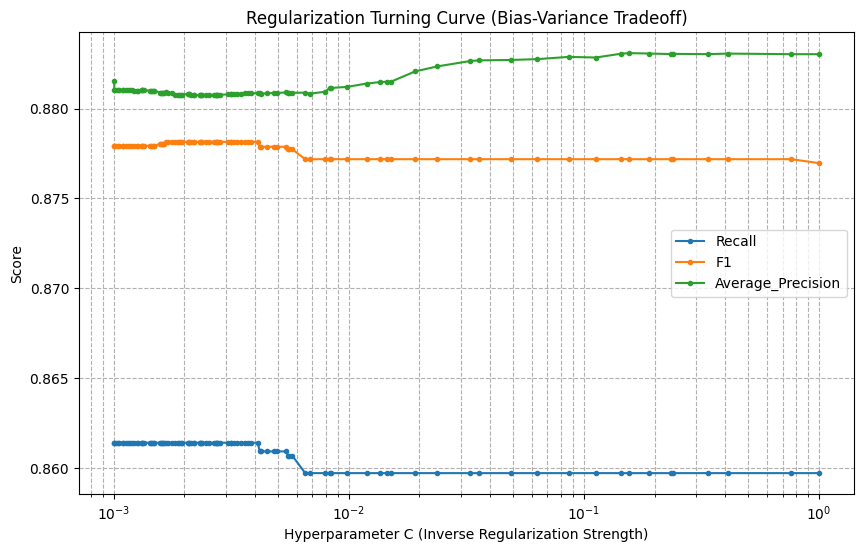

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract C (params) and the user-defined scores from all trials
records = []
for t in study.trials:
    if t.state == optuna.trial.TrialState.COMPLETE:
        records.append({
            "C": t.params["C"],
            "Class_weight": t.params.get("Class_weight"),
            "Recall": t.value,
            "F1": t.user_attrs["f1"],
            "Average_Precision": t.user_attrs["average_precision"]
        })

results_df = pd.DataFrame(records).sort_values("C")

# Plotting the Turning Curve
fig, ax = plt.subplots(figsize=(10, 6))
results_df.plot(x="C", y=["Recall", "F1", "Average_Precision"], ax=ax, style='.-')
ax.set_xscale('log')
ax.set_title("Regularization Turning Curve (Bias-Variance Tradeoff)")
ax.set_xlabel("Hyperparameter C (Inverse Regularization Strength)")
ax.set_ylabel("Score")
plt.grid(True, which="both", ls="--")
plt.show()


In [30]:
def objective(trial):
    c = trial.suggest_float("C", 0.001, 1.0)
    class_weight = trial.suggest_categorical("Class_weight", ['balanced', None])
    
    model = LogisticRegression(
        class_weight=class_weight,
        C=c,
        random_state=random_state
    )
    
    scores = cross_val_score(
        model, 
        X=X_train_scaled, 
        y=y_train, 
        cv=cv,
        scoring='f1',
        n_jobs=-1,
    )
    recall = scores.mean()
    
    return recall


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

log_reg_unscaled_f1_optuna_results = study.trials_dataframe().sort_values("value", ascending=False)
top_5_log_reg_unscaled_f1_optuna_results = study.trials_dataframe().sort_values("value", ascending=False).head(5)
display(top_5_log_reg_unscaled_f1_optuna_results)

[I 2026-06-26 21:12:53,934] A new study created in memory with name: no-name-aa543085-8c51-481b-a3af-71ceec0e1ceb
[I 2026-06-26 21:12:54,104] Trial 0 finished with value: 0.8770744551069047 and parameters: {'C': 0.7777290347229003, 'Class_weight': None}. Best is trial 0 with value: 0.8770744551069047.
[I 2026-06-26 21:12:54,261] Trial 1 finished with value: 0.8771824847322993 and parameters: {'C': 0.045247391775788584, 'Class_weight': 'balanced'}. Best is trial 1 with value: 0.8771824847322993.
[I 2026-06-26 21:12:54,421] Trial 2 finished with value: 0.8771824847322993 and parameters: {'C': 0.4854296765206533, 'Class_weight': None}. Best is trial 1 with value: 0.8771824847322993.
[I 2026-06-26 21:12:54,580] Trial 3 finished with value: 0.8771824847322993 and parameters: {'C': 0.2962933920732996, 'Class_weight': 'balanced'}. Best is trial 1 with value: 0.8771824847322993.
[I 2026-06-26 21:12:54,733] Trial 4 finished with value: 0.8771824847322993 and parameters: {'C': 0.0451144592045932

,number,value,datetime_start,datetime_complete,duration,params_C,params_Class_weight,state
65,65,0.878148,2026-06-26 21:13:04.275887,2026-06-26 21:13:04.425701,0 days 00:00:00.149814,0.001880,balanced,COMPLETE
66,66,0.878148,2026-06-26 21:13:04.425701,2026-06-26 21:13:04.564093,0 days 00:00:00.138392,0.002546,balanced,COMPLETE
63,63,0.878148,2026-06-26 21:13:03.980883,2026-06-26 21:13:04.123717,0 days 00:00:00.142834,0.002856,balanced,COMPLETE
61,61,0.878148,2026-06-26 21:13:03.679120,2026-06-26 21:13:03.809836,0 days 00:00:00.130716,0.003597,balanced,COMPLETE
68,68,0.878148,2026-06-26 21:13:04.723774,2026-06-26 21:13:04.876220,0 days 00:00:00.152446,0.003315,balanced,COMPLETE


##### Tryout best params

In [31]:
log_reg_recall_optimized_model = LogisticRegression(C=0.769946, class_weight='balanced', random_state=random_state)
log_reg_recall_optimized_model.fit(X_train_scaled, y_train)
y_pred = log_reg_recall_optimized_model.predict(X_test_scaled)
print(classification_report(y_true=y_test, y_pred=y_pred))
report = classification_report(y_true=y_test, y_pred=y_pred, output_dict=True)
df_temp = pd.DataFrame(report).transpose()

classification_reports.append(df_temp)
classification_report_keys.append('Logistic Regression (Recall Optimized)')

              precision    recall  f1-score   support

           0       0.88      0.89      0.89      1036
           1       0.89      0.88      0.88      1035

    accuracy                           0.89      2071
   macro avg       0.89      0.89      0.89      2071
weighted avg       0.89      0.89      0.89      2071



In [32]:
average_precision_score(y_true=y_test, y_score=y_pred)

0.8432307187875231

In [33]:
log_reg_f1_optimized_model = LogisticRegression(C=0.315005, class_weight='balanced', random_state=random_state)
log_reg_f1_optimized_model.fit(X_train_scaled, y_train)
y_pred = log_reg_f1_optimized_model.predict(X_test_scaled)
print(classification_report(y_true=y_test, y_pred=y_pred))
report = classification_report(y_true=y_test, y_pred=y_pred, output_dict=True)
df_temp = pd.DataFrame(report).transpose()

classification_reports.append(df_temp)
classification_report_keys.append('Logistic Regression (F1 Optimized)')

              precision    recall  f1-score   support

           0       0.88      0.89      0.89      1036
           1       0.89      0.88      0.88      1035

    accuracy                           0.89      2071
   macro avg       0.89      0.89      0.89      2071
weighted avg       0.89      0.89      0.89      2071



In [34]:
average_precision_score(y_true=y_test, y_score=y_pred)

0.8432307187875231

#### Ridge

In [35]:
# We can tune alpha and class weight

##### Recall optimized

In [36]:
def objective(trial):
    alpha = trial.suggest_float("alpha", 0.001, 1.0)
    class_weight = trial.suggest_categorical("class_weight", ['balanced', None])
    
    model = RidgeClassifier(
        class_weight=class_weight,
        alpha=alpha,
        random_state=random_state
    )
    
    scores = cross_val_score(
        model, 
        X=X_train_scaled, 
        y=y_train, 
        cv=cv,
        scoring='recall',
        n_jobs=-1,
    )
    recall = scores.mean()
    
    return recall


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

ridge_unscaled_recall_optuna_results = study.trials_dataframe().sort_values("value", ascending=False)
top_5_ridge_unscaled_recall_optuna_results = study.trials_dataframe().sort_values("value", ascending=False).head(5)
display(top_5_ridge_unscaled_recall_optuna_results)

[I 2026-06-26 21:13:09,932] A new study created in memory with name: no-name-0d876386-3819-4daa-8ec6-7947d2cb9c2c
[I 2026-06-26 21:13:10,085] Trial 0 finished with value: 0.8597323473365851 and parameters: {'alpha': 0.8011664463003736, 'class_weight': None}. Best is trial 0 with value: 0.8597323473365851.
[I 2026-06-26 21:13:10,242] Trial 1 finished with value: 0.8597323473365851 and parameters: {'alpha': 0.9487225871987265, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.8597323473365851.
[I 2026-06-26 21:13:10,383] Trial 2 finished with value: 0.8597323473365851 and parameters: {'alpha': 0.981133337136779, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.8597323473365851.
[I 2026-06-26 21:13:10,539] Trial 3 finished with value: 0.8597323473365851 and parameters: {'alpha': 0.5633759246067913, 'class_weight': None}. Best is trial 0 with value: 0.8597323473365851.
[I 2026-06-26 21:13:10,687] Trial 4 finished with value: 0.8597323473365851 and parameters: {'alpha': 0

,number,value,datetime_start,datetime_complete,duration,params_alpha,params_class_weight,state
0,0,0.859732,2026-06-26 21:13:09.933861,2026-06-26 21:13:10.085531,0 days 00:00:00.151670,0.801166,None,COMPLETE
1,1,0.859732,2026-06-26 21:13:10.085531,2026-06-26 21:13:10.242967,0 days 00:00:00.157436,0.948723,balanced,COMPLETE
2,2,0.859732,2026-06-26 21:13:10.242967,2026-06-26 21:13:10.383164,0 days 00:00:00.140197,0.981133,balanced,COMPLETE
3,3,0.859732,2026-06-26 21:13:10.384166,2026-06-26 21:13:10.539790,0 days 00:00:00.155624,0.563376,None,COMPLETE
4,4,0.859732,2026-06-26 21:13:10.539790,2026-06-26 21:13:10.687875,0 days 00:00:00.148085,0.901620,None,COMPLETE


##### Tryout best params

In [37]:
ridge_recall_optimized_model = RidgeClassifier(alpha=0.039558, class_weight='balanced', random_state=random_state)
ridge_recall_optimized_model.fit(X_train_scaled, y_train)
y_pred = ridge_recall_optimized_model.predict(X_test_scaled)
print(classification_report(y_true=y_test, y_pred=y_pred))
report = classification_report(y_true=y_test, y_pred=y_pred, output_dict=True)
df_temp = pd.DataFrame(report).transpose()

classification_reports.append(df_temp)
classification_report_keys.append('Ridge Classifier (Recall Optimized)')

              precision    recall  f1-score   support

           0       0.88      0.89      0.89      1036
           1       0.89      0.88      0.88      1035

    accuracy                           0.89      2071
   macro avg       0.89      0.89      0.89      2071
weighted avg       0.89      0.89      0.89      2071



In [38]:
average_precision_score(y_true=y_test, y_score=y_pred)

0.8432307187875231

##### F1 optimized

In [39]:
def objective(trial):
    alpha = trial.suggest_float("alpha", 0.001, 1.0)
    class_weight = trial.suggest_categorical("class_weight", ['balanced', None])
    
    model = RidgeClassifier(
        class_weight=class_weight,
        alpha=alpha,
        random_state=random_state
    )
    
    scores = cross_val_score(
        model, 
        X=X_train_scaled, 
        y=y_train, 
        cv=cv,
        scoring='f1',
        n_jobs=-1,
    )
    recall = scores.mean()
    
    return recall


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

ridge_unscaled_f1_optuna_results = study.trials_dataframe().sort_values("value", ascending=False)
top_5_ridge_unscaled_f1_optuna_results = study.trials_dataframe().sort_values("value", ascending=False).head(5)
display(top_5_ridge_unscaled_f1_optuna_results)

[I 2026-06-26 21:13:25,100] A new study created in memory with name: no-name-53cd1452-a576-490a-af6f-0294b547363b
[I 2026-06-26 21:13:25,249] Trial 0 finished with value: 0.8769665578707571 and parameters: {'alpha': 0.0965998752851704, 'class_weight': None}. Best is trial 0 with value: 0.8769665578707571.
[I 2026-06-26 21:13:25,388] Trial 1 finished with value: 0.8769665578707571 and parameters: {'alpha': 0.5842097144368261, 'class_weight': None}. Best is trial 0 with value: 0.8769665578707571.
[I 2026-06-26 21:13:25,545] Trial 2 finished with value: 0.8769665578707571 and parameters: {'alpha': 0.4601230098638064, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.8769665578707571.
[I 2026-06-26 21:13:25,706] Trial 3 finished with value: 0.8769665578707571 and parameters: {'alpha': 0.9824005933116424, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.8769665578707571.
[I 2026-06-26 21:13:25,848] Trial 4 finished with value: 0.8769665578707571 and parameters: {'alpha': 

,number,value,datetime_start,datetime_complete,duration,params_alpha,params_class_weight,state
0,0,0.876967,2026-06-26 21:13:25.100434,2026-06-26 21:13:25.249813,0 days 00:00:00.149379,0.096600,None,COMPLETE
1,1,0.876967,2026-06-26 21:13:25.250814,2026-06-26 21:13:25.388885,0 days 00:00:00.138071,0.584210,None,COMPLETE
2,2,0.876967,2026-06-26 21:13:25.388885,2026-06-26 21:13:25.545773,0 days 00:00:00.156888,0.460123,balanced,COMPLETE
3,3,0.876967,2026-06-26 21:13:25.545773,2026-06-26 21:13:25.706147,0 days 00:00:00.160374,0.982401,balanced,COMPLETE
4,4,0.876967,2026-06-26 21:13:25.707149,2026-06-26 21:13:25.848443,0 days 00:00:00.141294,0.720530,None,COMPLETE


##### Tryout best params

In [40]:
ridge_f1_optimized_model = RidgeClassifier(alpha=0.364826, class_weight='balanced', random_state=random_state)
ridge_f1_optimized_model.fit(X_train_scaled, y_train)
y_pred = ridge_f1_optimized_model.predict(X_test_scaled)
print(classification_report(y_true=y_test, y_pred=y_pred))
report = classification_report(y_true=y_test, y_pred=y_pred, output_dict=True)
df_temp = pd.DataFrame(report).transpose()

classification_reports.append(df_temp)
classification_report_keys.append('Ridge Classifier (F1 Optimized)')

              precision    recall  f1-score   support

           0       0.88      0.89      0.89      1036
           1       0.89      0.88      0.88      1035

    accuracy                           0.89      2071
   macro avg       0.89      0.89      0.89      2071
weighted avg       0.89      0.89      0.89      2071



In [41]:
average_precision_score(y_true=y_test, y_score=y_pred)

0.8432307187875231

[I 2026-06-26 21:13:40,412] A new study created in memory with name: no-name-063015c1-0dba-4a31-97e8-c1cc2b070622
[I 2026-06-26 21:13:40,561] Trial 0 finished with value: 0.8597323473365851 and parameters: {'alpha': 21.482141826988187}. Best is trial 0 with value: 0.8597323473365851.
[I 2026-06-26 21:13:40,711] Trial 1 finished with value: 0.8597323473365851 and parameters: {'alpha': 95.69252990132985}. Best is trial 0 with value: 0.8597323473365851.
[I 2026-06-26 21:13:40,865] Trial 2 finished with value: 0.8597323473365851 and parameters: {'alpha': 1.412769389591665}. Best is trial 0 with value: 0.8597323473365851.
[I 2026-06-26 21:13:41,016] Trial 3 finished with value: 0.8597323473365851 and parameters: {'alpha': 1.115806580151966}. Best is trial 0 with value: 0.8597323473365851.
[I 2026-06-26 21:13:41,170] Trial 4 finished with value: 0.8597323473365851 and parameters: {'alpha': 159.61663424461034}. Best is trial 0 with value: 0.8597323473365851.
[I 2026-06-26 21:13:41,319] Trial 

,alpha,recall,precision,f1
94,5439.403194,0.861905,0.894564,0.877883
53,5441.002120,0.861905,0.894564,0.877883
41,4097.028486,0.861905,0.894564,0.877883
75,4062.192478,0.861905,0.894564,0.877883
65,6027.063946,0.861905,0.894564,0.877883


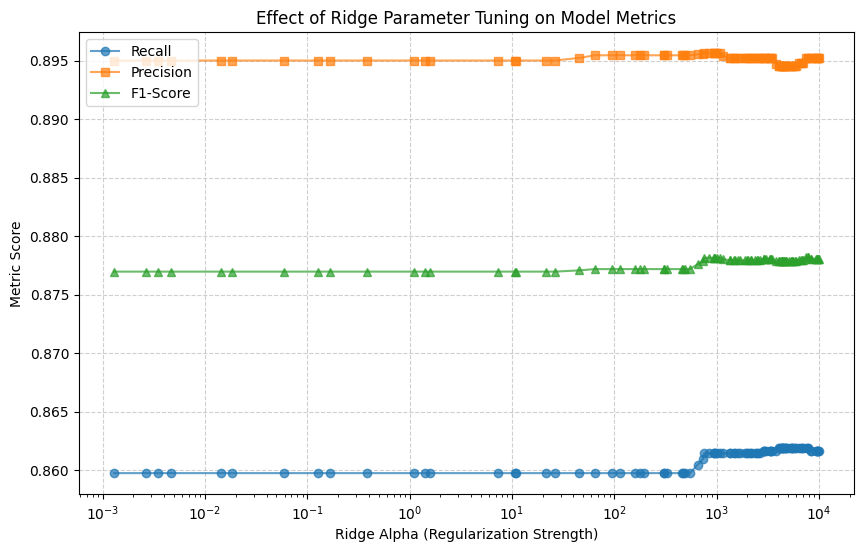

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate

def objective(trial):
    # Suggest hyperparameters
    alpha = trial.suggest_float("alpha", 0.001, 1_0000, log=True)
    # class_weight = trial.suggest_categorical("class_weight", ['balanced', None])
    
    model = RidgeClassifier(
        class_weight='balanced', 
        alpha=alpha, 
        random_state=random_state
    )
    
    # Evaluate multiple metrics simultaneously using cross_validate
    scoring_metrics = ['recall', 'precision', 'f1']
    cv_results = cross_validate(
        model, 
        X=X_train_scaled, 
        y=y_train, 
        cv=cv, 
        scoring=scoring_metrics, 
        n_jobs=-1
    )
    
    # Calculate the mean for each metric
    mean_recall = np.mean(cv_results['test_recall'])
    mean_precision = np.mean(cv_results['test_precision'])
    mean_f1 = np.mean(cv_results['test_f1'])
    
    # Save precision and F1 to trial metadata
    trial.set_user_attr("precision", mean_precision)
    trial.set_user_attr("f1", mean_f1)
    
    # Optuna will optimize based on recall
    return mean_recall

# Run the optimization study
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

# Convert study results to a DataFrame including user attributes
df_results = study.trials_dataframe()

# Rename columns for simpler plotting access
df_results = df_results.rename(columns={
    "value": "recall",
    "params_alpha": "alpha",
    "user_attrs_precision": "precision",
    "user_attrs_f1": "f1"
})

# Sort by alpha to ensure the plot line flows correctly
df_results = df_results.sort_values(by="alpha")

# Display the top 5 trials based on recall
top_5_results = df_results.sort_values("recall", ascending=False).head(5)
display(top_5_results[["alpha", "recall", "precision", "f1"]])

# Create a line plot to visualize the tuning effect
plt.figure(figsize=(10, 6))
ax = plt.gca() 
ax.set_xscale('log')
plt.plot(df_results["alpha"], df_results["recall"], label="Recall", marker="o", alpha=0.7)
plt.plot(df_results["alpha"], df_results["precision"], label="Precision", marker="s", alpha=0.7)
plt.plot(df_results["alpha"], df_results["f1"], label="F1-Score", marker="^", alpha=0.7)

ax.set_xscale('log')
plt.xlabel("Ridge Alpha (Regularization Strength)")
ax.set_xscale('log')
plt.ylabel("Metric Score")
plt.title("Effect of Ridge Parameter Tuning on Model Metrics")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


#### Lasso Logistic Regression

In [43]:
# We can only tune the C (float) and Class_weight to tryout balanced. 

In [44]:
def objective(trial):
    c = trial.suggest_float("C", 0.001, 1.0)
    class_weight = trial.suggest_categorical("Class_weight", ['balanced', None])
    
    model = LogisticRegression(
        penalty='l1', # Lasso
        class_weight=class_weight,
        C=c,
        solver='liblinear',
        random_state=random_state
    )
    
    scores = cross_val_score(
        model, 
        X=X_train_scaled, 
        y=y_train, 
        cv=cv,
        scoring='recall',
        n_jobs=-1,
    )
    recall = scores.mean()
    
    return recall


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15, n_jobs=-1)

lasso_unscaled_recall_optuna_results = study.trials_dataframe().sort_values("value", ascending=False)
top_5_lasso_unscaled_recall_optuna_results = study.trials_dataframe().sort_values("value", ascending=False).head(5)
display(top_5_lasso_unscaled_recall_optuna_results)

[I 2026-06-26 21:13:56,027] A new study created in memory with name: no-name-6061f276-3b14-42c0-9af8-1f47bf824c62
[I 2026-06-26 21:13:56,358] Trial 1 finished with value: 0.8597323473365851 and parameters: {'C': 0.1630150618936628, 'Class_weight': 'balanced'}. Best is trial 1 with value: 0.8597323473365851.
[I 2026-06-26 21:13:56,817] Trial 0 finished with value: 0.8597323473365851 and parameters: {'C': 0.399444473741617, 'Class_weight': 'balanced'}. Best is trial 1 with value: 0.8597323473365851.
[I 2026-06-26 21:13:57,029] Trial 6 finished with value: 0.8597323473365851 and parameters: {'C': 0.03333082071352235, 'Class_weight': None}. Best is trial 1 with value: 0.8597323473365851.
[I 2026-06-26 21:13:57,062] Trial 4 finished with value: 0.8597323473365851 and parameters: {'C': 0.43770850630881847, 'Class_weight': None}. Best is trial 1 with value: 0.8597323473365851.
[I 2026-06-26 21:13:57,065] Trial 8 finished with value: 0.8597323473365851 and parameters: {'C': 0.8570134848166622,

,number,value,datetime_start,datetime_complete,duration,params_C,params_Class_weight,state
0,0,0.859732,2026-06-26 21:13:56.030908,2026-06-26 21:13:56.817073,0 days 00:00:00.786165,0.399444,balanced,COMPLETE
1,1,0.859732,2026-06-26 21:13:56.032068,2026-06-26 21:13:56.358700,0 days 00:00:00.326632,0.163015,balanced,COMPLETE
2,2,0.859732,2026-06-26 21:13:56.033563,2026-06-26 21:13:57.123842,0 days 00:00:01.090279,0.780431,balanced,COMPLETE
3,3,0.859732,2026-06-26 21:13:56.035567,2026-06-26 21:13:57.216924,0 days 00:00:01.181357,0.579689,balanced,COMPLETE
4,4,0.859732,2026-06-26 21:13:56.037072,2026-06-26 21:13:57.062557,0 days 00:00:01.025485,0.437709,None,COMPLETE


In [45]:
def objective(trial):
    c = trial.suggest_float("C", 0.001, 1.0)
    class_weight = trial.suggest_categorical("Class_weight", ['balanced', None])
    
    model = LogisticRegression(
        penalty='l1', # Lasso
        class_weight=class_weight,
        C=c,
        solver='liblinear',
        random_state=random_state
    )
    
    scores = cross_val_score(
        model, 
        X=X_train_scaled, 
        y=y_train, 
        cv=cv,
        scoring='f1',
        n_jobs=-1,
    )
    recall = scores.mean()
    
    return recall


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15)

lasso_unscaled_f1_optuna_results = study.trials_dataframe().sort_values("value", ascending=False)
top_5_lasso_unscaled_f1_optuna_results = study.trials_dataframe().sort_values("value", ascending=False).head(5)
display(top_5_lasso_unscaled_f1_optuna_results)

[I 2026-06-26 21:13:57,284] A new study created in memory with name: no-name-8d1e4580-b338-4c99-ae97-9b1ee03f6a5d
[I 2026-06-26 21:13:57,533] Trial 0 finished with value: 0.8771824847322993 and parameters: {'C': 0.5743146641176424, 'Class_weight': 'balanced'}. Best is trial 0 with value: 0.8771824847322993.
[I 2026-06-26 21:13:57,752] Trial 1 finished with value: 0.8771824847322993 and parameters: {'C': 0.3201357223298019, 'Class_weight': 'balanced'}. Best is trial 0 with value: 0.8771824847322993.
[I 2026-06-26 21:13:58,014] Trial 2 finished with value: 0.8771824847322993 and parameters: {'C': 0.8760813395254339, 'Class_weight': 'balanced'}. Best is trial 0 with value: 0.8771824847322993.
[I 2026-06-26 21:13:58,223] Trial 3 finished with value: 0.8771824847322993 and parameters: {'C': 0.23204963493700473, 'Class_weight': 'balanced'}. Best is trial 0 with value: 0.8771824847322993.
[I 2026-06-26 21:13:58,414] Trial 4 finished with value: 0.8771824847322993 and parameters: {'C': 0.10069

,number,value,datetime_start,datetime_complete,duration,params_C,params_Class_weight,state
0,0,0.877182,2026-06-26 21:13:57.285823,2026-06-26 21:13:57.533186,0 days 00:00:00.247363,0.574315,balanced,COMPLETE
1,1,0.877182,2026-06-26 21:13:57.534294,2026-06-26 21:13:57.752834,0 days 00:00:00.218540,0.320136,balanced,COMPLETE
2,2,0.877182,2026-06-26 21:13:57.753835,2026-06-26 21:13:58.014872,0 days 00:00:00.261037,0.876081,balanced,COMPLETE
3,3,0.877182,2026-06-26 21:13:58.015876,2026-06-26 21:13:58.223928,0 days 00:00:00.208052,0.232050,balanced,COMPLETE
4,4,0.877182,2026-06-26 21:13:58.223928,2026-06-26 21:13:58.414450,0 days 00:00:00.190522,0.100695,None,COMPLETE


##### Tryout best params

In [46]:
lasso_recall_optimized_model = LogisticRegression(
    penalty='l1', # Lasso
    C=0.248927, 
    class_weight=None,
    solver='saga',
    random_state=random_state
)
lasso_recall_optimized_model.fit(X_train_scaled, y_train)
y_pred = lasso_recall_optimized_model.predict(X_test_scaled)
print(classification_report(y_true=y_test, y_pred=y_pred))
report = classification_report(y_true=y_test, y_pred=y_pred, output_dict=True)
df_temp = pd.DataFrame(report).transpose()

classification_reports.append(df_temp)
classification_report_keys.append('Lasso Classifier (Recall Optimized)')

              precision    recall  f1-score   support

           0       0.88      0.89      0.89      1036
           1       0.89      0.88      0.88      1035

    accuracy                           0.89      2071
   macro avg       0.89      0.89      0.89      2071
weighted avg       0.89      0.89      0.89      2071



c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [47]:
lasso_f1_optimized_model = LogisticRegression(
    penalty='l1', # Lasso
    C=0.496023, 
    class_weight=None,
    solver='saga',
    random_state=random_state
)
lasso_f1_optimized_model.fit(X_train_scaled, y_train)
y_pred = lasso_f1_optimized_model.predict(X_test_scaled)
print(classification_report(y_true=y_test, y_pred=y_pred))
report = classification_report(y_true=y_test, y_pred=y_pred, output_dict=True)
df_temp = pd.DataFrame(report).transpose()

classification_reports.append(df_temp)
classification_report_keys.append('Lasso Classifier (F1 Optimized)')

              precision    recall  f1-score   support

           0       0.88      0.89      0.89      1036
           1       0.89      0.88      0.88      1035

    accuracy                           0.89      2071
   macro avg       0.89      0.89      0.89      2071
weighted avg       0.89      0.89      0.89      2071



c:\Users\caleb\anaconda3\envs\iris-fisher\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [48]:
average_precision_score(y_true=y_test, y_score=y_pred)

0.8432307187875231

[I 2026-06-26 21:29:52,816] A new study created in memory with name: no-name-93568239-7bce-48e2-8e2e-0051d9d05c4f
[I 2026-06-26 21:29:55,344] Trial 12 finished with value: 0.8597323473365851 and parameters: {'C': 0.07282189343839271}. Best is trial 12 with value: 0.8597323473365851.
[I 2026-06-26 21:29:55,542] Trial 3 finished with value: 0.860939494064789 and parameters: {'C': 0.007401293044605266}. Best is trial 3 with value: 0.860939494064789.
[I 2026-06-26 21:29:55,556] Trial 4 finished with value: 0.8621469321631906 and parameters: {'C': 0.0018528855719944178}. Best is trial 4 with value: 0.8621469321631906.
[I 2026-06-26 21:29:55,566] Trial 14 finished with value: 0.8597323473365851 and parameters: {'C': 0.02185605621287477}. Best is trial 4 with value: 0.8621469321631906.
[I 2026-06-26 21:29:55,569] Trial 17 finished with value: 0.8621469321631906 and parameters: {'C': 0.0017363782444172072}. Best is trial 4 with value: 0.8621469321631906.
[I 2026-06-26 21:29:55,593] Trial 0 fin

,number,Recall,datetime_start,datetime_complete,duration,C,F1-Score,Precision,state
1,1,0.862147,2026-06-26 21:29:52.821135,2026-06-26 21:29:55.718210,0 days 00:00:02.897075,0.003929,0.871385,0.880941,COMPLETE
2,2,0.862147,2026-06-26 21:29:52.822139,2026-06-26 21:29:55.816748,0 days 00:00:02.994609,0.001545,0.871385,0.880941,COMPLETE
9,9,0.862147,2026-06-26 21:29:52.832153,2026-06-26 21:29:55.619428,0 days 00:00:02.787275,0.001732,0.871385,0.880941,COMPLETE
4,4,0.862147,2026-06-26 21:29:52.825544,2026-06-26 21:29:55.556585,0 days 00:00:02.731041,0.001853,0.871385,0.880941,COMPLETE
28,28,0.862147,2026-06-26 21:29:55.661748,2026-06-26 21:29:56.018226,0 days 00:00:00.356478,0.001973,0.871385,0.880941,COMPLETE


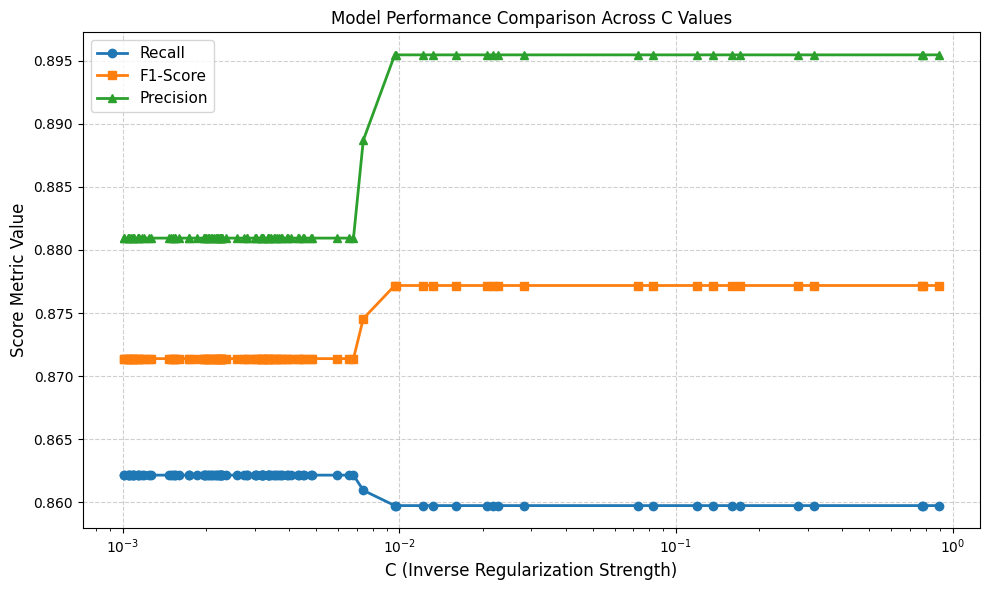

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import optuna
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate

def objective(trial):
    c = trial.suggest_float("C", 0.001, 1, log=True)
    
    model = LogisticRegression(
        penalty='l1',
        class_weight='balanced',
        C=c,
        solver='liblinear',
        random_state=random_state # Ensure random_state is defined in your environment
    )
    
    # Evaluate multiple metrics simultaneously
    scoring_metrics = ['recall', 'f1', 'precision']
    cv_results = cross_validate(
        model, 
        X=X_train_scaled, # Ensure X_train_scaled is defined
        y=y_train,        # Ensure y_train is defined
        cv=cv,            # Ensure cv object is defined
        scoring=scoring_metrics, 
        n_jobs=-1
    )
    
    # Calculate mean scores
    mean_recall = cv_results['test_recall'].mean()
    mean_f1 = cv_results['test_f1'].mean()
    # FIXED: Key must match the 'test_<metric>' pattern from scoring_metrics
    mean_precision = cv_results['test_precision'].mean() 
    
    # Store additional metrics inside the trial attributes
    trial.set_user_attr("f1", mean_f1)
    trial.set_user_attr("precision", mean_precision)
    
    # Optuna still optimizes strictly based on recall
    return mean_recall

# Run the study
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100, n_jobs=-1)

# Extract data including the user attributes
df_results = study.trials_dataframe()

# Clean up column names for easier plotting
df_results = df_results.rename(columns={
    'params_C': 'C',
    'value': 'Recall',
    'user_attrs_f1': 'F1-Score',
    'user_attrs_precision': 'Precision'
})

# Display Top 5 results sorted by Recall
top_5_results = df_results.sort_values("Recall", ascending=False).head(5)
display(top_5_results)

# Sort by C value to make line plotting continuous
df_plot = df_results.sort_values(by="C")

plt.figure(figsize=(10, 6))
ax = plt.gca()
ax.set_xscale('log')
# Plot each metric against C
plt.plot(df_plot['C'], df_plot['Recall'], marker='o', label='Recall', linewidth=2)
plt.plot(df_plot['C'], df_plot['F1-Score'], marker='s', label='F1-Score', linewidth=2)
plt.plot(df_plot['C'], df_plot['Precision'], marker='^', label='Precision', linewidth=2)

# Formatting the visual aesthetics
plt.title('Model Performance Comparison Across C Values')
plt.xlabel('C (Inverse Regularization Strength)', fontsize=12)
plt.ylabel('Score Metric Value', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()


### Conclusions

In [ ]:
pd.concat(classification_reports, keys=classification_report_keys)

precision    recall  \
Baseline Logistic Regression            0              1.000000  0.007722   
                                        1              0.501697  1.000000   
                                        accuracy       0.503621  0.503621   
                                        macro avg      0.750848  0.503861   
                                        weighted avg   0.750969  0.503621   
Baseline Ridge Classifier               0              0.880839  0.891892   
                                        1              0.890411  0.879227   
                                        accuracy       0.885563  0.885563   
                                        macro avg      0.885625  0.885559   
                                        weighted avg   0.885623  0.885563   
Baseline L1 (Lasso) Logistic Regression 0              0.880839  0.891892   
                                        1              0.890411  0.879227   
                                        accuracy       0.885563  0.885563   
                                        macro avg      0.885625  0.885559   
                                        weighted avg   0.885623  0.885563   
Logistic Regression (Recall Optimized)  0              0.880839  0.891892   
                                        1              0.890411  0.879227   
                                        accuracy       0.885563  0.885563   
                                        macro avg      0.885625  0.885559   
                                        weighted avg   0.885623  0.885563   
Logistic Regression (F1 Optimized)      0              0.880839  0.891892   
                                        1              0.890411  0.879227   
                                        accuracy       0.885563  0.885563   
                                        macro avg      0.885625  0.885559   
                                        weighted avg   0.885623  0.885563   
Ridge Classifier (Recall Optimized)     0              0.880839  0.891892   
                                        1              0.890411  0.879227   
                                        accuracy       0.885563  0.885563   
                                        macro avg      0.885625  0.885559   
                                        weighted avg   0.885623  0.885563   
Ridge Classifier (F1 Optimized)         0              0.880839  0.891892   
                                        1              0.890411  0.879227   
                                        accuracy       0.885563  0.885563   
                                        macro avg      0.885625  0.885559   
                                        weighted avg   0.885623  0.885563   
Lasso Classifier (Recall Optimized)     0              0.880839  0.891892   
                                        1              0.890411  0.879227   
                                        accuracy       0.885563  0.885563   
                                        macro avg      0.885625  0.885559   
                                        weighted avg   0.885623  0.885563   
Lasso Classifier (F1 Optimized)         0              0.880839  0.891892   
                                        1              0.890411  0.879227   
                                        accuracy       0.885563  0.885563   
                                        macro avg      0.885625  0.885559   
                                        weighted avg   0.885623  0.885563   

                                                      f1-score      support  
Baseline Logistic Regression            0             0.015326  1036.000000  
                                        1             0.668173  1035.000000  
                                        accuracy      0.503621     0.503621  
                                        macro avg     0.341749  2071.000000  
                                        weighted avg  0.341592  2071.000000  
Baseline Ridge Classifier               0  

The lasso and ridge both overcome poor initial performance of the logistic regression model

The logistic reg performance could have been poor due to severe multicollinearity or imbalanced feature scaling

In [ ]:
import numpy as np

pd.set_option('display.max_rows', None)

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Ridge_Coef': ridge_f1_optimized_model.coef_,
})

# Sort features by the absolute size of their coefficients
coef_df['Abs_Coefficient'] = np.abs(coef_df['Ridge_Coef'])
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)
coef_df

,Feature,Ridge_Coef,Abs_Coefficient
94,Payment Format_ACH,0.439854,0.439854
97,Payment Format_Cheque,-0.244206,0.244206
101,Account_Same,-0.235530,0.235530
98,Payment Format_Credit Card,-0.225024,0.225024
72,Receiving Currency_Saudi Riyal,0.203327,0.203327
87,Payment Currency_Saudi Riyal,-0.165397,0.165397
100,Payment Format_Wire,-0.123514,0.123514
96,Payment Format_Cash,-0.118390,0.118390
74,Receiving Currency_Swiss Franc,-0.108524,0.108524
89,Payment Currency_Swiss Franc,0.095514,0.095514


In [ ]:
len(coef_df[coef_df['Abs_Coefficient'] == 0])

60

We can see 60 features coefs get shrunk to 0 by the Ridge model. These all consist of the _Mean and _Median computed features which aimed to give a summary of average transactions for a given currency. This shows these features did not add additional information to the model and can be safely dropped

In [ ]:
coefficients = lasso_f1_optimized_model.coef_[0]

# 3. Create a DataFrame to map features to their coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients
})

# 4. VIEW RETAINED FEATURES (Coefficient is NOT 0)
selected_features = coef_df[coef_df['Coefficient'] != 0]
print("Features Selected by Lasso:")
print(selected_features)

# 5. VIEW REJECTED FEATURES (Coefficient is exactly 0)
dropped_features = coef_df[coef_df['Coefficient'] == 0]
print("\nFeatures Ignored by Lasso:")
print(dropped_features['Feature'].tolist())

Features Selected by Lasso:
                                  Feature  Coefficient
0                         Amount Received     0.017789
1                             Amount Paid     0.017961
2                     Amount_Received_USD    -0.016400
3                         Amount_Paid_USD    -0.016484
64   Receiving Currency_Australian Dollar    -0.038141
65             Receiving Currency_Bitcoin    -0.011198
66         Receiving Currency_Brazil Real    -0.017142
67     Receiving Currency_Canadian Dollar    -0.053279
68                Receiving Currency_Euro     0.033876
69        Receiving Currency_Mexican Peso    -0.008931
70               Receiving Currency_Ruble    -0.007914
71               Receiving Currency_Rupee    -0.014150
72         Receiving Currency_Saudi Riyal     0.141448
73              Receiving Currency_Shekel    -0.074872
74         Receiving Currency_Swiss Franc    -0.049205
75            Receiving Currency_UK Pound    -0.023084
76           Receiving Currency_US Do

We can see Lasso also removed some features during feature selection. The features consist of the same summary statistic features which Ridge shrunk the coefficients of.